In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.feature_selection import (
    RFE,
    SelectKBest,
    f_classif
)

from scipy.stats import randint

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print(X.head())

print()

print("Shape:", X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [3]:
print("Missing Values")

print(X.isnull().sum())

imputer = SimpleImputer(strategy="mean")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

Missing Values
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
results = {}

def evaluate_model(name, model, X_test, y_test):

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    results[name] = [
        accuracy,
        precision,
        recall,
        f1
    ]

    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, prediction))

    cm = confusion_matrix(y_test, prediction)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap="Blues")

    plt.title(name)

    plt.show()

Baseline
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



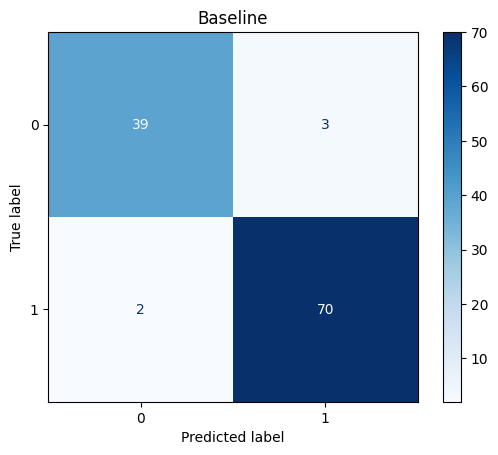

In [7]:
baseline = RandomForestClassifier(
    random_state=42
)

baseline.fit(
    X_train_scaled,
    y_train
)

evaluate_model(
    "Baseline",
    baseline,
    X_test_scaled,
    y_test
)

Best Parameters
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Grid Search
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



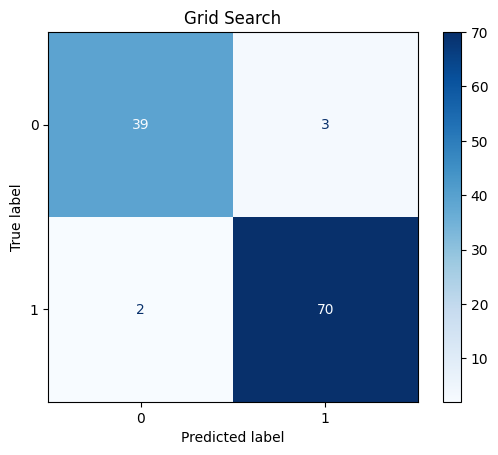

In [8]:
param_grid = {

    "n_estimators":[50,100,200],

    "max_depth":[3,5,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters")

print(grid.best_params_)

best_grid = grid.best_estimator_

evaluate_model(

    "Grid Search",

    best_grid,

    X_test_scaled,

    y_test
)

Best Parameters
{'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 268}
Random Search
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



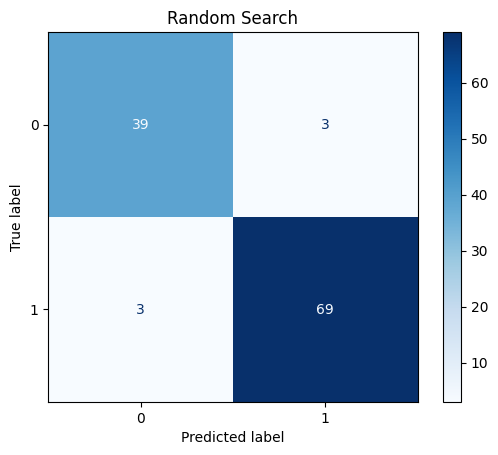

In [9]:
param_dist = {

    "n_estimators":randint(50,300),

    "max_depth":randint(2,20),

    "min_samples_split":randint(2,10),

    "min_samples_leaf":randint(1,5)

}

random_search = RandomizedSearchCV(

    RandomForestClassifier(random_state=42),

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    random_state=42,

    n_jobs=-1

)

random_search.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters")

print(random_search.best_params_)

best_random = random_search.best_estimator_

evaluate_model(

    "Random Search",

    best_random,

    X_test_scaled,

    y_test
)

RFE
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



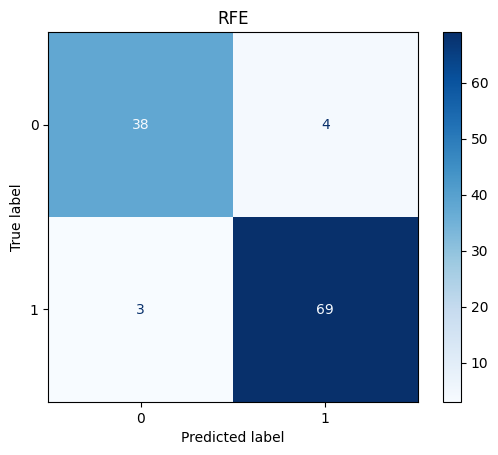

Index(['mean perimeter', 'mean area', 'mean concavity', 'mean concave points',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='object')


In [10]:
estimator = RandomForestClassifier(random_state=42)

rfe = RFE(

    estimator,

    n_features_to_select=10

)

X_train_rfe = rfe.fit_transform(

    X_train_scaled,

    y_train

)

X_test_rfe = rfe.transform(

    X_test_scaled

)

model_rfe = RandomForestClassifier(random_state=42)

model_rfe.fit(

    X_train_rfe,

    y_train

)

evaluate_model(

    "RFE",

    model_rfe,

    X_test_rfe,

    y_test
)

selected = X.columns[rfe.support_]

print(selected)

SelectKBest
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



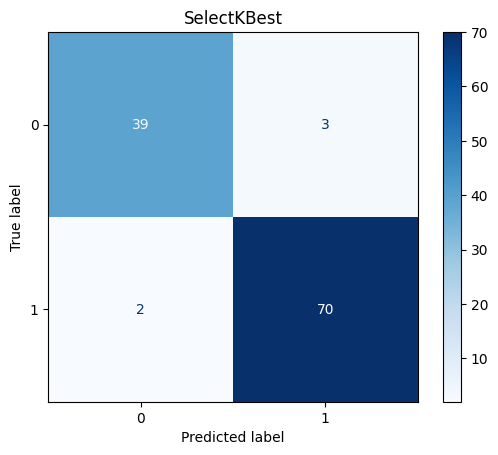

Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='object')


In [11]:
selector = SelectKBest(

    score_func=f_classif,

    k=10

)

X_train_k = selector.fit_transform(

    X_train_scaled,

    y_train

)

X_test_k = selector.transform(

    X_test_scaled

)

model_k = RandomForestClassifier(random_state=42)

model_k.fit(

    X_train_k,

    y_train

)

evaluate_model(

    "SelectKBest",

    model_k,

    X_test_k,

    y_test
)

selected_features = X.columns[selector.get_support()]

print(selected_features)

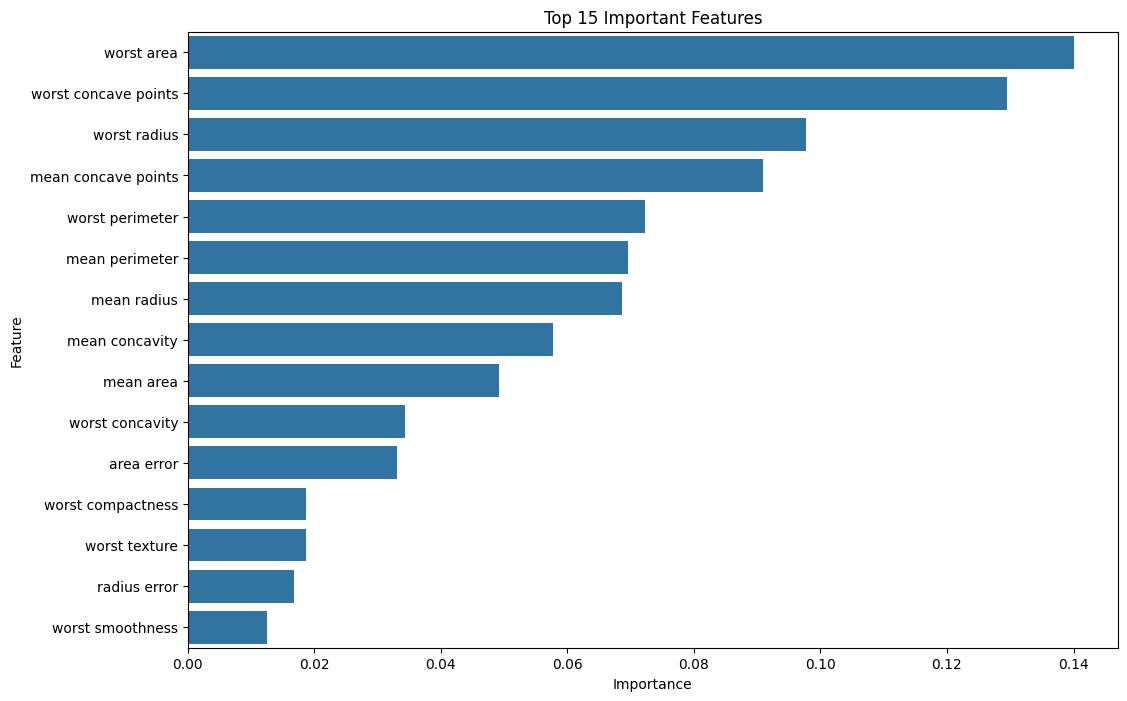

In [12]:
importance = baseline.feature_importances_

importance_df = pd.DataFrame({

    "Feature":X.columns,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.show()

In [13]:
comparison = pd.DataFrame(

    results,

    index=[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

).T

comparison

,Accuracy,Precision,Recall,F1 Score
Baseline,0.956140,0.958904,0.972222,0.965517
Grid Search,0.956140,0.958904,0.972222,0.965517
Random Search,0.947368,0.958333,0.958333,0.958333
RFE,0.938596,0.945205,0.958333,0.951724
SelectKBest,0.956140,0.958904,0.972222,0.965517


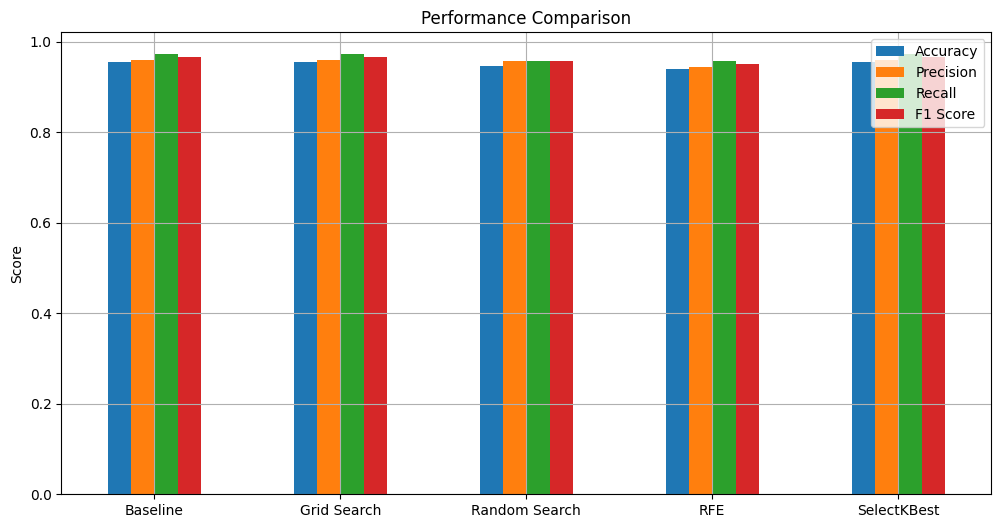

In [14]:
comparison.plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid()

plt.show()

In [15]:
print("="*60)
print("FINAL COMPARISON")
print("="*60)

print(comparison)

best = comparison["Accuracy"].idxmax()

print()

print("Best Model :", best)

print()

print("Conclusion")

print("- Hyperparameter tuning generally improves performance.")

print("- Grid Search checks every combination and is more exhaustive.")

print("- Random Search is faster and often finds competitive parameters.")

print("- RFE reduces features while maintaining high accuracy.")

print("- SelectKBest removes irrelevant features and speeds up training.")

print("- Random Forest Feature Importance explains which variables contribute the most.")

FINAL COMPARISON
               Accuracy  Precision    Recall  F1 Score
Baseline       0.956140   0.958904  0.972222  0.965517
Grid Search    0.956140   0.958904  0.972222  0.965517
Random Search  0.947368   0.958333  0.958333  0.958333
RFE            0.938596   0.945205  0.958333  0.951724
SelectKBest    0.956140   0.958904  0.972222  0.965517

Best Model : Baseline

Conclusion
- Hyperparameter tuning generally improves performance.
- Grid Search checks every combination and is more exhaustive.
- Random Search is faster and often finds competitive parameters.
- RFE reduces features while maintaining high accuracy.
- SelectKBest removes irrelevant features and speeds up training.
- Random Forest Feature Importance explains which variables contribute the most.
